# User Engagement Analysis

In [1]:
pip install pyodbc sqlalchemy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


### Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore
from sqlalchemy import create_engine

In [3]:
def load_and_clean_data():
    try:
        df = pd.read_csv(r'dataset/telcom_data (2).xlsx - Sheet1.csv')
        print("Data loaded successfully. Initial shape:", df.shape)
        
        # Clean numeric columns
        numeric_cols = ['Dur. (ms)', 'Total DL (Bytes)', 'Total UL (Bytes)']
        for col in numeric_cols:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(df[col].median())
        
        # Remove outliers using z-score
        z_scores = np.abs(zscore(df[numeric_cols]))
        threshold = 3
        df = df[(z_scores < threshold).all(axis=1)]
        print("Data after outlier removal:", df.shape)
        
        return df
    except Exception as e:
        print(f"Error in data loading/cleaning: {str(e)}")
        return None

In [4]:
def analyze_engagement(df):
    try:
        # Feature Engineering
        engagement_metrics = df.groupby('MSISDN/Number').agg(
            session_frequency=('Bearer Id', 'count'),
            total_duration=('Dur. (ms)', 'sum'),
            total_data=('Total DL (Bytes)', lambda x: (x.sum() + df.loc[x.index, 'Total UL (Bytes)'].sum()) / (1024**2))
        ).reset_index()

        # Normalize metrics
        scaler = StandardScaler()
        engagement_metrics[['norm_freq', 'norm_duration', 'norm_data']] = scaler.fit_transform(
            engagement_metrics[['session_frequency', 'total_duration', 'total_data']]
        )

        # Clustering
        kmeans = KMeans(n_clusters=3, random_state=42)
        engagement_metrics['cluster'] = kmeans.fit_predict(engagement_metrics[['norm_freq', 'norm_duration', 'norm_data']])

        # Visualization
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=engagement_metrics, x='total_data', y='session_frequency', hue='cluster', palette='viridis')
        plt.title('User Engagement Clusters')
        plt.xlabel('Total Data Usage (MB)')
        plt.ylabel('Session Frequency')
        plt.show()

        return engagement_metrics
    except Exception as e:
        print(f"Error in engagement analysis: {str(e)}")
        return None

In [5]:
def save_to_database(df, table_name):
    try:
        server = 'ANIKET\\SQLEXPRESS'
        database = 'telecom_analytics'
        connection_url = (
            f"mssql+pyodbc://@{server}/{database}"
            "?driver=ODBC+Driver+17+for+SQL+Server"
            "&trusted_connection=yes"
        )
        engine = create_engine(connection_url)

        # Clean column names for SQL
        df.columns = df.columns.str.replace('[^a-zA-Z0-9_]', '_', regex=True)

        # Save to dbo schema explicitly
        df.to_sql(name=table_name, con=engine, schema='dbo', if_exists='replace', index=False)

        print(f"Data saved to SQL Server table: dbo.{table_name}")
        engine.dispose()
    except Exception as e:
        print(f"Error saving to database: {str(e)}")

Data loaded successfully. Initial shape: (150001, 55)
Data after outlier removal: (147732, 55)


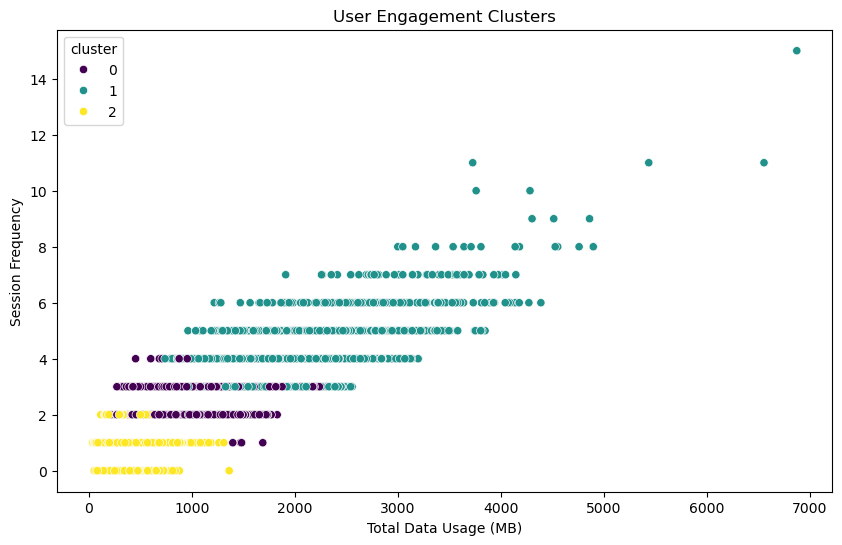

Data saved to SQL Server table: dbo.user_engagement_metrics
Top 10 Users by Data Usage:
       MSISDN_Number   total_data
36823   3.365973e+10  6872.071396
56869   3.366471e+10  6553.667267
75815   3.367588e+10  5434.753181
30533   3.365836e+10  4896.152781
24568   3.365043e+10  4860.047088
58674   3.366519e+10  4758.354902
61793   3.366617e+10  4550.902257
85696   3.369876e+10  4526.222693
1638    3.360658e+10  4512.278943
59302   3.366535e+10  4387.362709


In [6]:
# Main execution
if __name__ == "__main__":
    df = load_and_clean_data()
    if df is not None:
        engagement_metrics = analyze_engagement(df)
        if engagement_metrics is not None:
            save_to_database(engagement_metrics, 'user_engagement_metrics')
             # Save to CSV
            engagement_metrics.to_csv(r'dataset/engagement_metrics.csv', index=False)
            
            print("Top 10 Users by Data Usage:")
            print(engagement_metrics.nlargest(10, 'total_data')[['MSISDN_Number', 'total_data']])